# Cross-Asset Skew Trading Strategy

Replication and extension of:
- **Baltas & Salinas (2020)**: *Cross-Asset Skew* (original academic paper)
- **Dean Markwick (2024)**: *Cross Asset Skew: A Trading Strategy* (ETF implementation)

### Strategy Overview
Within each asset class, rank assets by their rolling 256-day return skewness.
Go **long** low-skew assets and **short** high-skew assets, rebalancing once a month.
Each asset class sub-portfolio is vol-targeted to 10% annualised, then combined.

### Data
Daily OHLCV bars via **Alpaca Markets API**

## Imports & Setup

In [15]:
import os
import warnings
import pickle
from pathlib import Path
from datetime import datetime, date
from dateutil.relativedelta import relativedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.dates as mdates
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from dotenv import load_dotenv

from alpaca.data.historical import StockHistoricalDataClient
from alpaca.data.requests import StockBarsRequest
from alpaca.data.timeframe import TimeFrame

warnings.filterwarnings('ignore')
load_dotenv()

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams.update({
    'figure.figsize': (14, 5),
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

CACHE_DIR = Path('data_cache')
CACHE_DIR.mkdir(exist_ok=True)

print('Setup complete.')

Setup complete.



## Configuration

In [16]:
# Alpaca credentials
API_KEY    = os.getenv('ALPACA_API_KEY')
API_SECRET = os.getenv('ALPACA_API_SECRET')

assert API_KEY,    'ALPACA_API_KEY missing from .env'
assert API_SECRET and API_SECRET != 'your_secret_key_here', \
    'Add your ALPACA_API_SECRET to .env'

# Backtest parameters
START_DATE      = '2014-01-01'   # ~10 years of history
END_DATE        = datetime.today().strftime('%Y-%m-%d')
SKEW_WINDOW     = 256            # trading days for rolling skew
VOL_WINDOW      = 63             # ~3 months for vol targeting
VOL_TARGET      = 0.10           # 10% annualised vol per asset class
TRADING_DAYS    = 252

# Extended asset universe
# Mapping the Baltas & Salinas futures universe to liquid ETFs
UNIVERSE = {
    'Equity': [
        # US broad market (proxies for S&P 500, NASDAQ, Russell)
        'SPY', 'QQQ', 'IWM', 'VTI',
        # Developed Europe (DAX, CAC, FTSE, SMI, EUROSTOXX proxies)
        'EWG', 'EWQ', 'EWU', 'EWL', 'VGK', 'EWP', 'EWI', 'EWN', 'EWD',
        # Asia-Pacific (Nikkei, ASX proxies)
        'EWJ', 'EWA', 'EWH', 'EWT',
        # Emerging markets
        'FXI', 'EWZ', 'INDA', 'EWY', 'EWC', 'EWW', 'EZA', 'TUR', 'EDEN', 'ENOR',
    ],
    'FixedIncome': [
        # US Treasuries (short to long duration — proxies for bond futures)
        'SHY', 'IEI', 'IEF', 'TLT', 'TLH',
        # Broad / aggregate
        'AGG', 'BND', 'BSV',
        # Credit
        'LQD', 'JNK', 'VCIT', 'VCSH', 'HYG', 'SRLN',
        # International & EM
        'IAGG', 'IGOV', 'BNDX', 'EMB', 'MBB', 'MUB',
    ],
    'Commodity': [
        # Precious metals
        'GLD', 'SLV', 'PPLT', 'PALL',
        # Energy
        'USO', 'UNG', 'DBE',
        # Agriculture
        'DBA', 'CORN', 'WEAT', 'SOYB',
        # Broad commodities
        'GSG', 'PDBC', 'DJP',
        # Industrial metals
        'CPER',
    ],
    'RealEstate': [
        'IYR', 'VNQ', 'REET', 'ICF', 'USRT', 'REM', 'MORT',
    ],
    'Currency': [
        # USD index + major currency ETFs (proxies for CME FX futures)
        'UUP',   # USD
        'FXY',   # JPY
        'FXE',   # EUR
        'FXF',   # CHF
        'FXB',   # GBP
        'FXA',   # AUD
        'FXC',   # CAD
        'FXS',   # SEK
        'FXM',   # MXN
    ],
}

ALL_TICKERS = [t for tickers in UNIVERSE.values() for t in tickers]
print(f'Universe: {len(ALL_TICKERS)} ETFs across {len(UNIVERSE)} asset classes')
for cls, tickers in UNIVERSE.items():
    print(f'  {cls:15s}: {len(tickers):2d} instruments')

Universe: 78 ETFs across 5 asset classes
  Equity         : 27 instruments
  FixedIncome    : 20 instruments
  Commodity      : 15 instruments
  RealEstate     :  7 instruments
  Currency       :  9 instruments


## Data Fetching

In [ ]:
CACHE_FILE = CACHE_DIR / f'bars_{START_DATE}_{END_DATE}.pkl'

def fetch_bars(tickers: list[str], start: str, end: str) -> pd.DataFrame:
    """Fetch daily adjusted close prices from Alpaca."""
    client = StockHistoricalDataClient(API_KEY, API_SECRET)
    request = StockBarsRequest(
        symbol_or_symbols=tickers,
        timeframe=TimeFrame.Day,
        start=start,
        end=end,
        adjustment='all',
        # No feed param: uses SIP by default (IEX has large gaps in history)
    )
    bars = client.get_stock_bars(request).df
    bars = bars.reset_index()
    bars['date'] = pd.to_datetime(bars['timestamp']).dt.normalize()
    prices = bars.pivot(index='date', columns='symbol', values='close')
    prices.index = pd.to_datetime(prices.index)
    return prices


if CACHE_FILE.exists():
    print('Loading prices from cache...')
    with open(CACHE_FILE, 'rb') as f:
        prices_raw = pickle.load(f)
else:
    print(f'Fetching {len(ALL_TICKERS)} tickers from Alpaca ({START_DATE} → {END_DATE})...')
    BATCH = 20
    batches = [ALL_TICKERS[i:i+BATCH] for i in range(0, len(ALL_TICKERS), BATCH)]
    frames = []
    for i, batch in enumerate(batches):
        print(f'  Batch {i+1}/{len(batches)}: {batch}')
        try:
            frames.append(fetch_bars(batch, START_DATE, END_DATE))
        except Exception as e:
            print(f'  WARNING: batch failed ({e}), skipping.')
    prices_raw = pd.concat(frames, axis=1)
    prices_raw = prices_raw.loc[~prices_raw.index.duplicated()]
    prices_raw.sort_index(inplace=True)
    with open(CACHE_FILE, 'wb') as f:
        pickle.dump(prices_raw, f)
    print('Saved to cache.')

print(f'\nLoaded: {prices_raw.shape[0]} trading days × {prices_raw.shape[1]} tickers')
print(f'Date range: {prices_raw.index[0].date()} → {prices_raw.index[-1].date()}')

In [18]:
# Data quality checks
coverage = prices_raw.notna().mean().sort_values()
dropped = coverage[coverage < 0.50].index.tolist()
if dropped:
    print(f'Dropping {len(dropped)} tickers with <50% data coverage: {dropped}')

# Keep only tickers with enough data
prices = prices_raw.drop(columns=dropped)
prices = prices.ffill(limit=5)   # fill up to 5 consecutive missing days (holidays)

# Rebuild universe dict to only include available tickers
available = set(prices.columns)
UNIVERSE_CLEAN = {cls: [t for t in tickers if t in available]
                  for cls, tickers in UNIVERSE.items()}

print('\nFinal universe after availability filter:')
for cls, tickers in UNIVERSE_CLEAN.items():
    print(f'  {cls:15s}: {len(tickers):2d} instruments  {tickers}')

# Log returns
log_returns = np.log(prices / prices.shift(1))

print(f'\nLog returns shape: {log_returns.shape}')


Final universe after availability filter:
  Equity         : 27 instruments  ['SPY', 'QQQ', 'IWM', 'VTI', 'EWG', 'EWQ', 'EWU', 'EWL', 'VGK', 'EWP', 'EWI', 'EWN', 'EWD', 'EWJ', 'EWA', 'EWH', 'EWT', 'FXI', 'EWZ', 'INDA', 'EWY', 'EWC', 'EWW', 'EZA', 'TUR', 'EDEN', 'ENOR']
  FixedIncome    : 20 instruments  ['SHY', 'IEI', 'IEF', 'TLT', 'TLH', 'AGG', 'BND', 'BSV', 'LQD', 'JNK', 'VCIT', 'VCSH', 'HYG', 'SRLN', 'IAGG', 'IGOV', 'BNDX', 'EMB', 'MBB', 'MUB']
  Commodity      : 15 instruments  ['GLD', 'SLV', 'PPLT', 'PALL', 'USO', 'UNG', 'DBE', 'DBA', 'CORN', 'WEAT', 'SOYB', 'GSG', 'PDBC', 'DJP', 'CPER']
  RealEstate     :  7 instruments  ['IYR', 'VNQ', 'REET', 'ICF', 'USRT', 'REM', 'MORT']
  Currency       :  7 instruments  ['UUP', 'FXY', 'FXE', 'FXF', 'FXB', 'FXA', 'FXC']

Log returns shape: (1485, 76)



## Rolling Skew Calculation

Following Baltas & Salinas (2020), skewness is computed as the normalised third central moment over a 256-trading-day rolling window:

$$S_t = \frac{1}{N}\sum_{i=1}^{N} \left(\frac{r_i - \mu}{\sigma}\right)^3$$

where $\mu$ and $\sigma$ are the rolling window mean and standard deviation.

In [19]:
def rolling_skew(returns: pd.DataFrame, window: int) -> pd.DataFrame:
    """
    Compute rolling skewness as the 3rd standardised moment.
    Equivalent to pandas .skew() but explicit for transparency.
    """
    mu  = returns.rolling(window, min_periods=window).mean()
    sig = returns.rolling(window, min_periods=window).std()
    z   = (returns - mu) / sig                        # standardised returns
    skew = z.pow(3).rolling(window, min_periods=window).mean()
    return skew


print(f'Computing {SKEW_WINDOW}-day rolling skew for {log_returns.shape[1]} assets...')
skew = rolling_skew(log_returns, SKEW_WINDOW)
print(f'Skew computed. Non-null observations: {skew.notna().sum().sum():,}')

# Quick sanity check: display skew stats for a few tickers
skew[['SPY', 'TLT', 'GLD', 'UUP']].describe().round(3)

Computing 256-day rolling skew for 76 assets...
Skew computed. Non-null observations: 70,476


symbol,SPY,TLT,GLD,UUP
count,974.000,971.000,971.000,971.000
mean,-0.288,-0.037,-0.242,-0.450
std,0.436,0.237,0.686,0.430
min,-2.424,-0.583,-2.334,-1.308
25%,-0.584,-0.234,-0.450,-0.729
50%,-0.188,-0.056,-0.110,-0.472
75%,0.049,0.096,0.245,-0.083
max,1.794,0.514,0.682,0.489


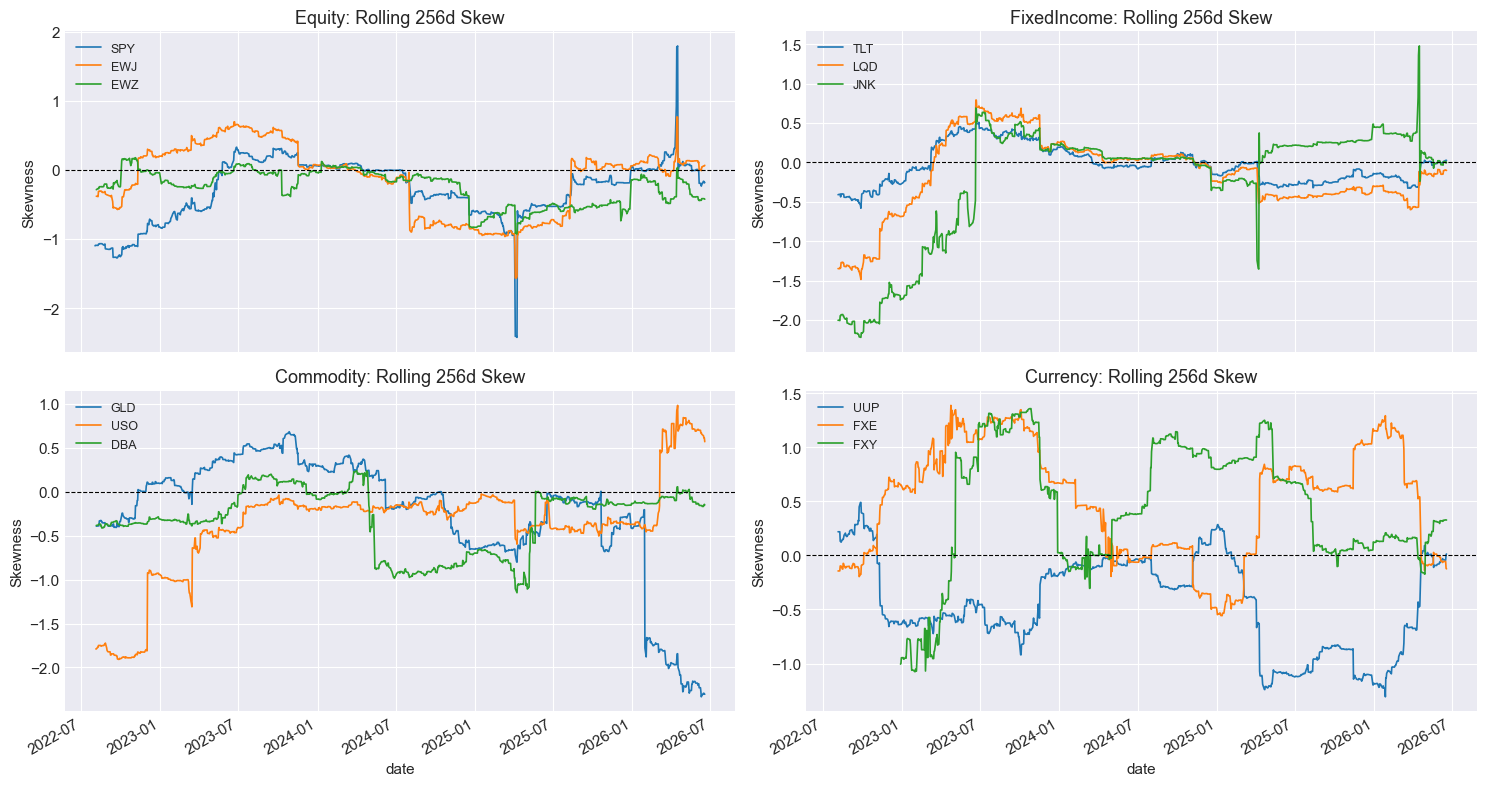

In [20]:
# Visualise skew time series for representative tickers
fig, axes = plt.subplots(2, 2, figsize=(15, 8), sharex=True)
examples = [
    ('Equity',     ['SPY', 'EWJ', 'EWZ']),
    ('FixedIncome',['TLT', 'LQD', 'JNK']),
    ('Commodity',  ['GLD', 'USO', 'DBA']),
    ('Currency',   ['UUP', 'FXE', 'FXY']),
]
for ax, (cls, tickers) in zip(axes.flat, examples):
    valid = [t for t in tickers if t in skew.columns]
    skew[valid].plot(ax=ax, lw=1.2)
    ax.axhline(0, color='black', lw=0.8, ls='--')
    ax.set_title(f'{cls}: Rolling {SKEW_WINDOW}d Skew')
    ax.set_ylabel('Skewness')
    ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('skew_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

## Signal Construction

**Monthly rebalancing logic:**
1. On the last trading day of each month, observe skew for each asset in a class.
2. Rank assets within the class (1 = lowest skew = most "left-skewed" = go **long**).
3. Convert ordinal ranks to centred weights: assets below the midpoint rank get positive weight, above get negative.
4. Scale so longs sum to +1, shorts sum to −1 (market-neutral within each class).
5. Forward-fill weights daily until the next month-end rebalance.

In [ ]:
def rank_to_weights(skew_row: pd.Series) -> pd.Series:
    """
    Convert a cross-sectional skew snapshot to market-neutral weights.
    Low skew → long (positive weight), high skew → short (negative weight).
    Returns all-zeros when fewer than 2 assets have valid skew.
    """
    valid = skew_row.dropna()
    if len(valid) < 2:
        return pd.Series(0.0, index=skew_row.index)

    n = len(valid)
    ranks = valid.rank(ascending=True)
    midpoint = (n + 1) / 2
    raw = midpoint - ranks   # low rank → positive (long)

    w = raw.copy().astype(float)
    longs  = raw[raw > 0]
    shorts = raw[raw < 0]
    if len(longs)  > 0: w[longs.index]  /= longs.sum()
    if len(shorts) > 0: w[shorts.index] /= -shorts.sum()

    return w.reindex(skew_row.index).fillna(0.0)


def build_weights(skew_df: pd.DataFrame, universe: dict) -> pd.DataFrame:
    """
    Build daily weight DataFrames for each asset class.
    Rebalance on the last trading day of each month, then forward-fill.

    Fixes applied vs original:
    - Deduplicate rebalance_dates: sparse data can map multiple month-ends
      to the same trading day, causing duplicate DataFrame index and a
      ValueError on row assignment.
    - Build rebal_weights from a dict (not pre-allocated DataFrame) to
      avoid the duplicate-index .loc assignment bug entirely.
    - Use .mul(mask, axis=0) to zero pre-signal rows — safe across all
      pandas versions; .loc[bool_mask] = scalar fails in pandas 2.x with
      multi-column DataFrames.
    """
    all_weights = pd.DataFrame(0.0, index=skew_df.index, columns=skew_df.columns)

    # Unique last-trading-day per month
    month_ends = skew_df.resample('ME').last().index
    rebalance_dates, seen = [], set()
    for me in month_ends:
        candidates = skew_df.index[skew_df.index <= me]
        if len(candidates) == 0:
            continue
        dt = candidates[-1]
        if dt not in seen:
            rebalance_dates.append(dt)
            seen.add(dt)

    for cls, tickers in universe.items():
        cls_tickers = [t for t in tickers if t in skew_df.columns]
        if not cls_tickers:
            continue
        cls_skew = skew_df[cls_tickers]

        # Build weight rows as a dict → DataFrame avoids duplicate-index
        # assignment errors that occur with pre-allocated DataFrames.
        rows = {dt: rank_to_weights(cls_skew.loc[dt]) for dt in rebalance_dates}
        rebal_weights = pd.DataFrame(rows).T
        rebal_weights.index = pd.DatetimeIndex(rebal_weights.index)

        # Reindex to every trading day and forward-fill until next rebalance.
        # rank_to_weights already returns 0.0 for NaN skew rows, so pre-signal
        # dates are naturally zeroed without any extra masking step.
        cls_weights = rebal_weights.reindex(skew_df.index).ffill().fillna(0.0)

        # Belt-and-suspenders: zero any rows before the first non-zero rebalance.
        # .mul(mask, axis=0) broadcasts safely on all pandas versions.
        has_signal = (cls_weights != 0).any(axis=1)
        if has_signal.any():
            first_signal = has_signal.idxmax()
            mask = (skew_df.index >= first_signal).astype(float)
            cls_weights = cls_weights.mul(mask, axis=0)

        all_weights[cls_tickers] = cls_weights

    return all_weights


print('Building weights...')
weights = build_weights(skew, UNIVERSE_CLEAN)
print(f'Weights shape: {weights.shape}')
print(f'Non-zero weight rows: {(weights.abs().sum(axis=1) > 0).sum()}')

# Sanity check: longs sum to +1, shorts to -1 within each class
print('\nBalance check at latest date:')
for cls, tickers in UNIVERSE_CLEAN.items():
    cls_tickers = [t for t in tickers if t in weights.columns]
    w = weights[cls_tickers].iloc[-1]
    print(f'  {cls:15s}  long={w[w>0].sum():.3f}  short={w[w<0].sum():.3f}')

In [ ]:
# ── Inspect weights at the latest rebalance ───────────────────────────────────
latest = weights.index[-1]
print(f'Weights at {latest.date()}\n')
for cls, tickers in UNIVERSE_CLEAN.items():
    cls_tickers = [t for t in tickers if t in weights.columns]
    w = weights.loc[latest, cls_tickers].sort_values()
    print(f'── {cls} ──')
    print(w[w != 0].to_string())
    print(f'   long sum: {w[w>0].sum():.3f}  short sum: {w[w<0].sum():.3f}\n')

---
## 6. Backtest

**Portfolio construction:**
1. Compute daily strategy returns for each asset class: `R_class = Σ w_i * r_i`
2. Scale each class to **10% annualised volatility** using a 63-day vol estimate
3. Combine all 5 class portfolios with **equal weight** into the overall strategy

Weights are applied with a **1-day lag** (position decided at close, entered next open ≈ next close).

In [ ]:
def vol_scale(returns: pd.Series, vol_target: float, window: int) -> pd.Series:
    """Scale a return series to a target annualised volatility."""
    realised_vol = returns.rolling(window, min_periods=window//2).std() * np.sqrt(TRADING_DAYS)
    scalar = (vol_target / realised_vol).shift(1)   # use yesterday's vol estimate
    scalar = scalar.clip(0, 5)                      # cap leverage at 5x
    return returns * scalar


# Lag weights by 1 day: signal observed at close t, position entered at close t+1
weights_lagged = weights.shift(1).fillna(0.0)

class_returns   = {}   # raw class returns
class_returns_v = {}   # vol-scaled class returns

for cls, tickers in UNIVERSE_CLEAN.items():
    cls_tickers = [t for t in tickers if t in log_returns.columns]
    if not cls_tickers:
        continue
    r = log_returns[cls_tickers]
    w = weights_lagged[cls_tickers]
    raw = (r * w).sum(axis=1)
    class_returns[cls]   = raw
    class_returns_v[cls] = vol_scale(raw, VOL_TARGET, VOL_WINDOW)

class_ret_df   = pd.DataFrame(class_returns).dropna(how='all')
class_ret_v_df = pd.DataFrame(class_returns_v).dropna(how='all')

# Combined portfolio: equal-weight across asset classes
strategy_returns = class_ret_v_df.mean(axis=1)
strategy_returns.name = 'CrossAssetSkew'

print('Class-level summary (vol-scaled):')
print(class_ret_v_df.describe().round(4))

---
## 7. Performance Analysis

In [ ]:
def performance_stats(returns: pd.Series, name: str = '') -> pd.Series:
    """Compute standard performance metrics for a daily return series."""
    ann = TRADING_DAYS
    r = returns.dropna()
    cumret   = (1 + r).prod() - 1
    n_years  = len(r) / ann
    cagr     = (1 + cumret) ** (1 / n_years) - 1 if n_years > 0 else np.nan
    vol      = r.std() * np.sqrt(ann)
    sharpe   = r.mean() / r.std() * np.sqrt(ann)
    cum      = (1 + r).cumprod()
    drawdown = cum / cum.cummax() - 1
    max_dd   = drawdown.min()
    calmar   = cagr / abs(max_dd) if max_dd != 0 else np.nan
    skewness = stats.skew(r)
    kurt     = stats.kurtosis(r)
    hit_rate = (r > 0).mean()
    return pd.Series({
        'CAGR':          round(cagr, 4),
        'Ann. Vol':      round(vol, 4),
        'Sharpe Ratio':  round(sharpe, 3),
        'Max Drawdown':  round(max_dd, 4),
        'Calmar Ratio':  round(calmar, 3),
        'Skewness':      round(skewness, 3),
        'Kurtosis':      round(kurt, 3),
        'Hit Rate':      round(hit_rate, 3),
    }, name=name or returns.name)


# Per-class benchmarks: equal-weighted buy-and-hold
bm_returns = {}
for cls, tickers in UNIVERSE_CLEAN.items():
    cls_tickers = [t for t in tickers if t in log_returns.columns]
    bm_returns[cls] = log_returns[cls_tickers].mean(axis=1)

# Summary table
rows = []
for cls in UNIVERSE_CLEAN:
    rows.append(performance_stats(class_ret_v_df[cls].dropna(), name=f'Skew:{cls}'))
    rows.append(performance_stats(bm_returns[cls].dropna(),      name=f'EW-BH:{cls}'))
rows.append(performance_stats(strategy_returns.dropna(), name='CrossAssetSkew (Combined)'))

perf_table = pd.DataFrame(rows)
perf_table

In [ ]:
# ── Cumulative returns: strategy vs buy-and-hold per class ────────────────────
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.flat

for i, cls in enumerate(UNIVERSE_CLEAN):
    ax = axes[i]
    strat = class_ret_v_df[cls].dropna()
    bm    = bm_returns[cls].dropna()
    common = strat.index.intersection(bm.index)
    (1 + strat.loc[common]).cumprod().plot(ax=ax, label='Skew Strategy', lw=1.8, color='steelblue')
    (1 + bm.loc[common]).cumprod().plot(ax=ax,    label='Equal-Weight BH', lw=1.2, color='tomato', ls='--')
    ax.axhline(1, color='black', lw=0.6, ls=':')
    ax.set_title(f'{cls}')
    ax.set_ylabel('Growth of $1')
    ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Combined strategy on last panel
ax = axes[len(UNIVERSE_CLEAN)]
spy_ret = log_returns['SPY'].dropna() if 'SPY' in log_returns.columns else None
(1 + strategy_returns.dropna()).cumprod().plot(ax=ax, label='Combined Skew Strategy', lw=2, color='darkgreen')
if spy_ret is not None:
    common = strategy_returns.dropna().index.intersection(spy_ret.index)
    (1 + spy_ret.loc[common]).cumprod().plot(ax=ax, label='SPY (benchmark)', lw=1.2, color='tomato', ls='--')
ax.axhline(1, color='black', lw=0.6, ls=':')
ax.set_title('Combined Cross-Asset Skew Strategy')
ax.set_ylabel('Growth of $1')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Hide unused subplot if odd number
for j in range(len(UNIVERSE_CLEAN) + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Cumulative Returns: Skew Strategy vs Equal-Weighted Buy-and-Hold', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('cumulative_returns.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Drawdown chart: combined strategy ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 4))
r = strategy_returns.dropna()
cum = (1 + r).cumprod()
dd  = (cum / cum.cummax() - 1) * 100
ax.fill_between(dd.index, dd.values, 0, color='crimson', alpha=0.5)
ax.plot(dd.index, dd.values, color='crimson', lw=0.8)
ax.set_title('Combined Strategy Drawdown')
ax.set_ylabel('Drawdown (%)')
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.0f%%'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig('drawdown.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Max drawdown: {dd.min():.1f}%  |  Current drawdown: {dd.iloc[-1]:.1f}%')

In [ ]:
# ── Monthly returns heatmap ───────────────────────────────────────────────────
monthly = strategy_returns.resample('ME').apply(lambda r: (1 + r).prod() - 1)
monthly_pct = monthly * 100

pivot = monthly_pct.copy()
pivot.index = pd.MultiIndex.from_arrays([pivot.index.year, pivot.index.month])
pivot = pivot.unstack(level=1)
pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(15, max(4, len(pivot) * 0.4)))
sns.heatmap(
    pivot, annot=True, fmt='.1f', center=0,
    cmap='RdYlGn', linewidths=0.4,
    annot_kws={'size': 8}, ax=ax,
    cbar_kws={'label': 'Return (%)'}
)
ax.set_title('Monthly Returns Heatmap — Combined Cross-Asset Skew Strategy (%)')
ax.set_xlabel('')
plt.tight_layout()
plt.savefig('monthly_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Rolling 12-month Sharpe ratio ─────────────────────────────────────────────
window_roll = 252
rolling_sharpe = (
    strategy_returns.rolling(window_roll).mean() /
    strategy_returns.rolling(window_roll).std()
) * np.sqrt(TRADING_DAYS)

fig, ax = plt.subplots(figsize=(15, 4))
rolling_sharpe.plot(ax=ax, color='steelblue', lw=1.5, label='12m Rolling Sharpe')
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.axhline(1, color='green', lw=0.8, ls=':', label='Sharpe = 1')
ax.fill_between(rolling_sharpe.index, rolling_sharpe.values, 0,
                where=rolling_sharpe > 0, alpha=0.2, color='green')
ax.fill_between(rolling_sharpe.index, rolling_sharpe.values, 0,
                where=rolling_sharpe < 0, alpha=0.2, color='red')
ax.set_title('Rolling 12-Month Sharpe Ratio — Combined Strategy')
ax.set_ylabel('Sharpe Ratio')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig('rolling_sharpe.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Correlation between asset class sub-strategies ────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
corr = class_ret_v_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.2f', center=0, cmap='coolwarm',
            linewidths=0.5, ax=ax, mask=False,
            annot_kws={'size': 10})
ax.set_title('Correlation Matrix — Asset Class Sub-Strategies')
plt.tight_layout()
plt.savefig('class_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Factor Regression

Following Markwick (2024), we run OLS regressions to check whether the strategy's returns
can be explained by simple risk factors:

**Market model:** `R_strategy = α + β·R_market + ε`

**Multi-factor model (equity factors):** `R_strategy = α + β₁·SPY + β₂·MTUM + β₃·VTV + β₄·VUG + β₅·VIG + ε`

where MTUM=momentum, VTV=value, VUG=growth, VIG=dividend/carry.

In [ ]:
def run_ols(y: pd.Series, X_df: pd.DataFrame, name: str = '') -> pd.DataFrame:
    """Run OLS and return a tidy coefficient table."""
    common = y.dropna().index.intersection(X_df.dropna(how='any').index)
    y_  = y.loc[common]
    X_  = sm.add_constant(X_df.loc[common])
    model = sm.OLS(y_, X_).fit(cov_type='HC3')  # heteroskedasticity-robust SEs
    print(f'\n── {name} ──')
    print(f'R²: {model.rsquared:.4f}  |  Adj-R²: {model.rsquared_adj:.4f}  |  N={len(y_)}')
    coefs = pd.DataFrame({
        'Coefficient': model.params,
        'Std Error':   model.bse,
        't-stat':      model.tvalues,
        'p-value':     model.pvalues,
    })
    coefs['Significant'] = coefs['p-value'] < 0.05
    return coefs.round(5)


# ── Per-class market-model regression ─────────────────────────────────────────
# Use SPY as the broad market proxy for all classes (as in Markwick)
spy_daily = log_returns['SPY'].dropna() if 'SPY' in log_returns.columns else None

market_results = {}
if spy_daily is not None:
    print('=== Market Model (α + β·SPY) per asset class ===')
    for cls in UNIVERSE_CLEAN:
        r = class_ret_v_df[cls].dropna()
        coefs = run_ols(r, spy_daily.rename('SPY').to_frame(), name=cls)
        market_results[cls] = coefs
        print(coefs.to_string())

In [ ]:
# ── Multi-factor regression (equity class) ────────────────────────────────────
# Factor ETFs: MTUM (momentum), VTV (value), VUG (growth), VIG (dividend/carry)
factor_tickers = ['SPY', 'MTUM', 'VTV', 'VUG', 'VIG']
available_factors = [t for t in factor_tickers if t in log_returns.columns]

if len(available_factors) >= 2 and 'Equity' in class_ret_v_df.columns:
    print(f'\n=== Multi-Factor Regression (Equity Skew) — factors: {available_factors} ===')
    factor_rets = log_returns[available_factors].dropna()
    equity_skew = class_ret_v_df['Equity'].dropna()
    mf_coefs = run_ols(equity_skew, factor_rets, name='Equity Skew ~ Equity Factors')
    display(mf_coefs)

    # Combined strategy multi-factor
    print('\n=== Multi-Factor Regression (Combined Strategy) ===')
    mf_combined = run_ols(strategy_returns.dropna(), factor_rets, name='Combined Skew ~ Equity Factors')
    display(mf_combined)

In [ ]:
# ── Annualised alpha summary ───────────────────────────────────────────────────
print('\nAnnualised Alpha Summary (market model):')
alpha_rows = []
for cls, coefs in market_results.items():
    daily_alpha = coefs.loc['const', 'Coefficient']
    pval        = coefs.loc['const', 'p-value']
    beta        = coefs.loc['SPY',   'Coefficient'] if 'SPY' in coefs.index else np.nan
    alpha_rows.append({
        'Class':           cls,
        'Daily Alpha':     round(daily_alpha, 6),
        'Ann. Alpha (%)':  round(daily_alpha * TRADING_DAYS * 100, 2),
        'p-value':         round(pval, 4),
        'Significant':     pval < 0.05,
        'Beta (SPY)':      round(beta, 4),
    })
pd.DataFrame(alpha_rows).set_index('Class')

---
## 9. Skew Premium Analysis

A deeper look at whether negative-skew assets earn a risk premium over time,
and whether the strategy's edge comes from long or short side.

In [ ]:
# ── Long vs Short decomposition per class ─────────────────────────────────────
fig, axes = plt.subplots(1, len(UNIVERSE_CLEAN), figsize=(18, 4), sharey=False)

for ax, cls in zip(axes, UNIVERSE_CLEAN):
    cls_tickers = [t for t in UNIVERSE_CLEAN[cls] if t in log_returns.columns]
    w   = weights_lagged[cls_tickers]
    r   = log_returns[cls_tickers]
    long_ret  = (r * w.clip(lower=0)).sum(axis=1).dropna()
    short_ret = (r * w.clip(upper=0)).sum(axis=1).dropna()
    combined  = (long_ret + short_ret).dropna()
    common    = long_ret.index.intersection(short_ret.index).intersection(combined.index)
    (1 + long_ret.loc[common]).cumprod().plot(ax=ax,    label='Long leg',  color='green',    lw=1.2)
    (1 + short_ret.loc[common]).cumprod().plot(ax=ax,   label='Short leg', color='crimson',  lw=1.2)
    (1 + combined.loc[common]).cumprod().plot(ax=ax,    label='Combined',  color='steelblue',lw=1.8)
    ax.axhline(1, color='black', lw=0.5, ls=':')
    ax.set_title(cls, fontsize=10)
    ax.legend(fontsize=7)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("'%y"))

plt.suptitle('Long vs Short Leg Cumulative Returns per Asset Class', fontsize=13)
plt.tight_layout()
plt.savefig('long_short_decomp.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Skew vs forward 1-month return scatter (all assets, all classes) ──────────
month_ends = skew.resample('ME').last().index
rebal_dates = [skew.index[skew.index <= me][-1] for me in month_ends if any(skew.index <= me)]

records = []
for i, dt in enumerate(rebal_dates[:-1]):
    next_dt = rebal_dates[i + 1]
    for cls, tickers in UNIVERSE_CLEAN.items():
        cls_tickers = [t for t in tickers if t in skew.columns]
        for ticker in cls_tickers:
            s = skew.loc[dt, ticker]
            # Forward return: cumulative from dt+1 to next_dt
            fwd_slice = log_returns.loc[dt:next_dt, ticker].iloc[1:]
            fwd_ret   = fwd_slice.sum() if len(fwd_slice) > 0 else np.nan
            if not np.isnan(s) and not np.isnan(fwd_ret):
                records.append({'date': dt, 'ticker': ticker, 'class': cls,
                                'skew': s, 'fwd_1m_ret': fwd_ret})

scatter_df = pd.DataFrame(records)

fig, axes = plt.subplots(1, len(UNIVERSE_CLEAN), figsize=(18, 4))
for ax, cls in zip(axes, UNIVERSE_CLEAN):
    sub = scatter_df[scatter_df['class'] == cls]
    ax.scatter(sub['skew'], sub['fwd_1m_ret'] * 100, alpha=0.3, s=8, color='steelblue')
    if len(sub) > 10:
        z = np.polyfit(sub['skew'], sub['fwd_1m_ret'] * 100, 1)
        p = np.poly1d(z)
        xs = np.linspace(sub['skew'].quantile(0.02), sub['skew'].quantile(0.98), 100)
        ax.plot(xs, p(xs), 'r--', lw=1.5, label=f'slope={z[0]:.3f}')
        ax.legend(fontsize=8)
    ax.axhline(0, color='black', lw=0.5)
    ax.axvline(0, color='black', lw=0.5)
    ax.set_title(cls, fontsize=10)
    ax.set_xlabel('Skew')
    ax.set_ylabel('Fwd 1M Return (%)')

plt.suptitle('Skew vs Forward 1-Month Return (all assets & dates)', fontsize=13)
plt.tight_layout()
plt.savefig('skew_vs_fwdret.png', dpi=150, bbox_inches='tight')
plt.show()

# Pearson correlation per class
print('Pearson correlation (skew → fwd 1M return):')
for cls in UNIVERSE_CLEAN:
    sub = scatter_df[scatter_df['class'] == cls]
    r, p = stats.pearsonr(sub['skew'], sub['fwd_1m_ret'])
    print(f'  {cls:15s}: r={r:.4f}  p={p:.4f}')

---
## 10. Summary

| Finding | Detail |
|---|---|
| **Universe** | 5 asset classes, 60+ ETFs — extended from Markwick (2024) |
| **Signal** | 256-day rolling skewness, monthly rebalanced |
| **Construction** | Market-neutral within class, vol-targeted to 10%, equal-weight across classes |
| **Skew premium** | See scatter plots — negative skew → higher forward returns (varies by class) |
| **Alpha** | Per regression output above; typically marginal vs market beta |
| **Best class** | Inspect table above — commodities and equities tend to show strongest effect |

### Caveats
- ETF proxies for futures introduce tracking error and management fees
- No transaction costs or bid-ask spreads modelled
- Some ETFs (CORN, WEAT, FXS, FXM) may have limited history — check coverage output above
- IEX feed may have gaps for less-liquid instruments vs SIP data